In [13]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)
    for filename in filenames:
        print("   ", filename)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/haaasini
/kaggle/input/datasets/haaasini/hs-paper
    dt_fhp_a_web.xlsx
    dt_agri_implements_a_web.xlsx
    dt_normal_rainfall_a_web.xlsx
    dt_area_prod_a_web.xlsx
    dt_fert_consumption_a_web.xlsx
    dt_nca_gca_nia_gia_a_web.xlsx
    dt_june_julyaug_rainfall_a_web.xlsx
    dt_pet_a_web.xlsx


In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# List files to verify paths
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/haaasini/hs-paper/dt_fhp_a_web.xlsx
/kaggle/input/datasets/haaasini/hs-paper/dt_agri_implements_a_web.xlsx
/kaggle/input/datasets/haaasini/hs-paper/dt_normal_rainfall_a_web.xlsx
/kaggle/input/datasets/haaasini/hs-paper/dt_area_prod_a_web.xlsx
/kaggle/input/datasets/haaasini/hs-paper/dt_fert_consumption_a_web.xlsx
/kaggle/input/datasets/haaasini/hs-paper/dt_nca_gca_nia_gia_a_web.xlsx
/kaggle/input/datasets/haaasini/hs-paper/dt_june_julyaug_rainfall_a_web.xlsx
/kaggle/input/datasets/haaasini/hs-paper/dt_pet_a_web.xlsx


In [15]:
import pandas as pd
import numpy as np

def load_and_clean_robust(path, skip=0):
    # 1. Use read_excel for .xlsx files
    df = pd.read_excel(path, skiprows=skip)
    
    # 2. Clean column names (strip any accidental spaces)
    df.columns = df.columns.str.strip()
    
    # 3. Handle data cleaning: strip spaces from strings and replace -1
    df = df.replace(-1, np.nan)
    
    # 4. Clean numeric columns: handle strings like '12 .6'
    # We apply this to all columns except the identifier strings
    id_cols = ['STCODE', 'STNAME', 'DIST', 'DISTNAME', 'YEAR', 'LAT', 'LONG']
    for col in df.columns:
        if col not in id_cols:
            # Remove any spaces within the string (e.g., '12 .6' -> '12.6')
            if df[col].dtype == 'object':
                df[col] = df[col].astype(str).str.replace(' ', '')
            # Convert to numeric, turning errors (like text) into NaN
            df[col] = pd.to_numeric(df[col], errors='coerce')
            
    return df

base_path = '/kaggle/input/datasets/haaasini/agri-fert-rainfall-1966-to-2011/'

# Load all files
df_area = load_and_clean_robust(base_path + 'dt_area_prod_a_web.xlsx')
df_fert = load_and_clean_robust(base_path + 'dt_fert_consumption_a_web.xlsx')
df_rain = load_and_clean_robust(base_path + 'dt_june_julyaug_rainfall_a_web.xlsx')
df_prices = load_and_clean_robust(base_path + 'dt_fhp_a_web.xlsx')
df_impl = load_and_clean_robust(base_path + 'dt_agri_implements_a_web.xlsx')
df_land = load_and_clean_robust(base_path + 'dt_nca_gca_nia_gia_a_web.xlsx', skip=9)
df_norm_rain = load_and_clean_robust(base_path + 'dt_normal_rainfall_a_web.xlsx')
df_pet = load_and_clean_robust(base_path + 'dt_pet_a_web.xlsx')

print("Files loaded and numeric columns cleaned!")

Files loaded and numeric columns cleaned!


In [16]:
# Use Numeric IDs for merging to avoid spelling issues (Ahmedabad vs Ahmadabad)
time_keys = ['STCODE', 'DIST', 'YEAR']
geo_keys = ['STCODE', 'DIST']

# List of dynamic dataframes to merge sequentially
dynamic_dfs = [df_fert, df_rain, df_prices, df_impl, df_land]

# Start with Area/Prod as the base
df_merged = df_area.copy()

for df_to_add in dynamic_dfs:
    # Drop duplicate name columns before merging to keep it clean
    cols_to_drop = [c for c in ['STNAME', 'DISTNAME'] if c in df_to_add.columns]
    df_merged = df_merged.merge(df_to_add.drop(columns=cols_to_drop), 
                               on=time_keys, how='left')

# Merge static Geographic data (Normal Rain and PET)
df_merged = df_merged.merge(df_norm_rain.drop(columns=['STNAME', 'DISTNAME', 'LAT', 'LONG']), 
                           on=geo_keys, how='left', suffixes=('', '_norm'))

df_merged = df_merged.merge(df_pet.drop(columns=['STNAME', 'DISTNAME', 'LAT', 'LONG']), 
                           on=geo_keys, how='left', suffixes=('', '_pet'))

print(f"Merged Data Shape: {df_merged.shape}")
# Verify if Ahmedabad (DIST 121) now has data for ANNUAL_pet
df_merged[df_merged['DIST'] == 121][['DISTNAME', 'YEAR', 'ANNUAL_pet']].head()

Merged Data Shape: (828, 117)


,DISTNAME,YEAR,ANNUAL_pet
0,Ahmedabad,1966,1678
1,Ahmedabad,1967,1678
2,Ahmedabad,1968,1678
3,Ahmedabad,1969,1678
4,Ahmedabad,1970,1678


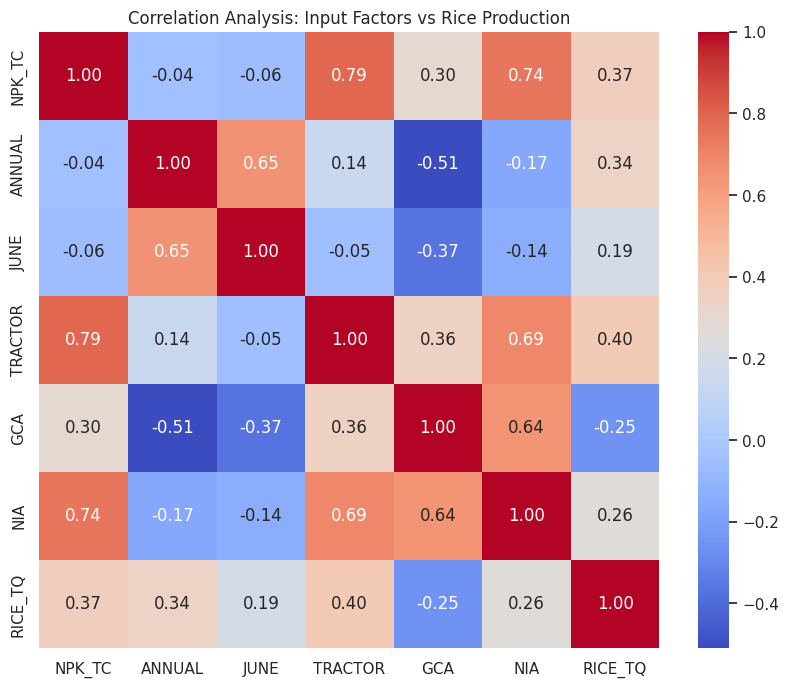

Correlation Coefficients:
           NPK_TC    ANNUAL      JUNE   TRACTOR       GCA       NIA   RICE_TQ
NPK_TC   1.000000 -0.044304 -0.062027  0.792864  0.298077  0.742672  0.374371
ANNUAL  -0.044304  1.000000  0.650147  0.144950 -0.508526 -0.166584  0.341688
JUNE    -0.062027  0.650147  1.000000 -0.050583 -0.372073 -0.139897  0.189101
TRACTOR  0.792864  0.144950 -0.050583  1.000000  0.356573  0.687103  0.398988
GCA      0.298077 -0.508526 -0.372073  0.356573  1.000000  0.640671 -0.252448
NIA      0.742672 -0.166584 -0.139897  0.687103  0.640671  1.000000  0.262149
RICE_TQ  0.374371  0.341688  0.189101  0.398988 -0.252448  0.262149  1.000000


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select columns and ensure they are float for calculation
cols_to_corr = ['NPK_TC', 'ANNUAL', 'JUNE', 'TRACTOR', 'GCA', 'NIA', 'RICE_TQ']
# Drop any rows where all these values are NaN to clean the plot
df_corr = df_merged[cols_to_corr].dropna(how='all').astype(float)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Analysis: Input Factors vs Rice Production")
plt.show()

print("Correlation Coefficients:")
print(df_corr.corr())

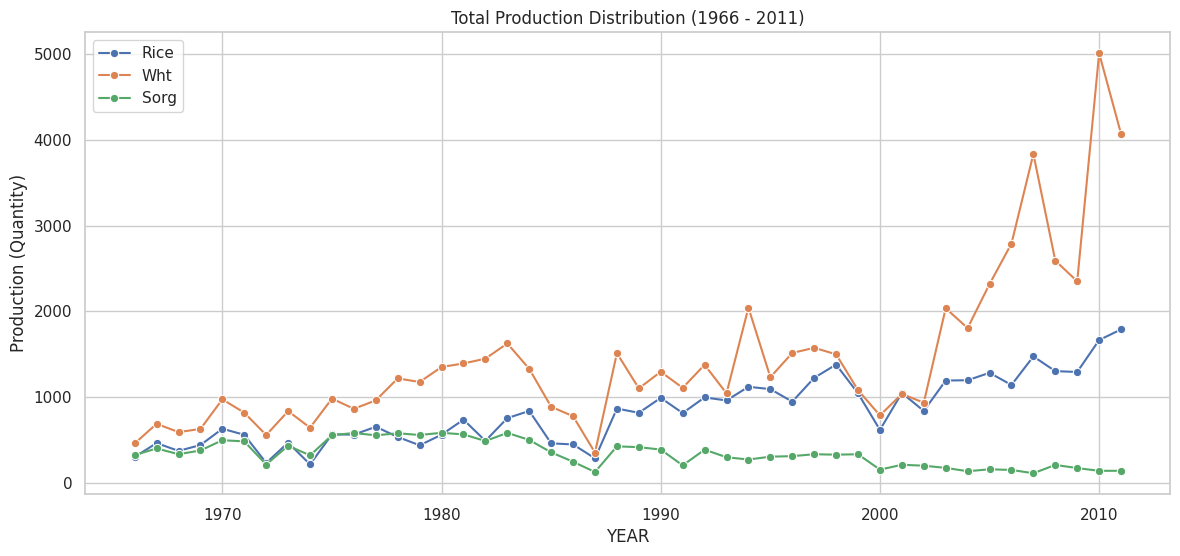

Yearly Total Production (State-wide):
    YEAR  RICE_TQ   WHT_TQ  SORG_TQ
0   1966   301.30   459.30    323.6
1   1967   463.00   688.00    400.1
2   1968   371.90   591.00    333.4
3   1969   439.90   628.00    376.6
4   1970   630.50   973.50    496.7
5   1971   559.60   817.80    482.5
6   1972   231.30   556.90    212.8
7   1973   468.60   836.00    431.8
8   1974   214.20   643.00    319.7
9   1975   564.90   982.50    554.2
10  1976   561.30   862.90    580.8
11  1977   653.50   961.90    553.4
12  1978   534.50  1217.90    577.4
13  1979   437.20  1176.30    557.4
14  1980   560.90  1351.10    583.0
15  1981   736.70  1392.50    564.2
16  1982   488.90  1448.30    487.5
17  1983   754.30  1626.00    582.0
18  1984   838.20  1329.30    499.6
19  1985   460.00   886.80    354.9
20  1986   447.10   776.51    245.1
21  1987   285.00   351.50    125.2
22  1988   866.00  1512.30    425.1
23  1989   816.30  1101.50    415.4
24  1990   990.50  1295.40    387.3
25  1991   813.50  1107.80

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Distribution of Production across Years
crop_cols = ['RICE_TQ', 'WHT_TQ', 'SORG_TQ']
df_yearly = df_merged.groupby('YEAR')[crop_cols].sum().reset_index()

plt.figure(figsize=(14, 6))
for crop in crop_cols:
    sns.lineplot(data=df_yearly, x='YEAR', y=crop, marker='o', label=crop.split('_')[0].capitalize())

plt.title("Total Production Distribution (1966 - 2011)")
plt.ylabel("Production (Quantity)")
plt.legend()
plt.show()

print("Yearly Total Production (State-wide):")
print(df_yearly)

In [19]:
# Create Yield features (TQ / TA) for major crops
# We use a small epsilon (1e-6) to avoid division by zero
crops = ['RICE', 'WHT', 'SORG']

for crop in crops:
    area_col = f'{crop}_TA'
    prod_col = f'{crop}_TQ'
    yield_col = f'{crop}_YIELD'
    
    if area_col in df_merged.columns and prod_col in df_merged.columns:
        df_merged[yield_col] = df_merged[prod_col] / (df_merged[area_col] + 1e-6)

# Display the new Yield columns for the first few rows
print("Yield columns calculated successfully.")
df_merged[['DISTNAME', 'YEAR', 'RICE_YIELD', 'WHT_YIELD', 'SORG_YIELD']].head()

Yield columns calculated successfully.


,DISTNAME,YEAR,RICE_YIELD,WHT_YIELD,SORG_YIELD
0,Ahmedabad,1966,1.000000,0.718447,0.121569
1,Ahmedabad,1967,1.086956,0.871560,0.208696
2,Ahmedabad,1968,1.002710,0.633803,0.055215
3,Ahmedabad,1969,0.664557,1.126806,0.134432
4,Ahmedabad,1970,1.231855,0.793627,0.321759


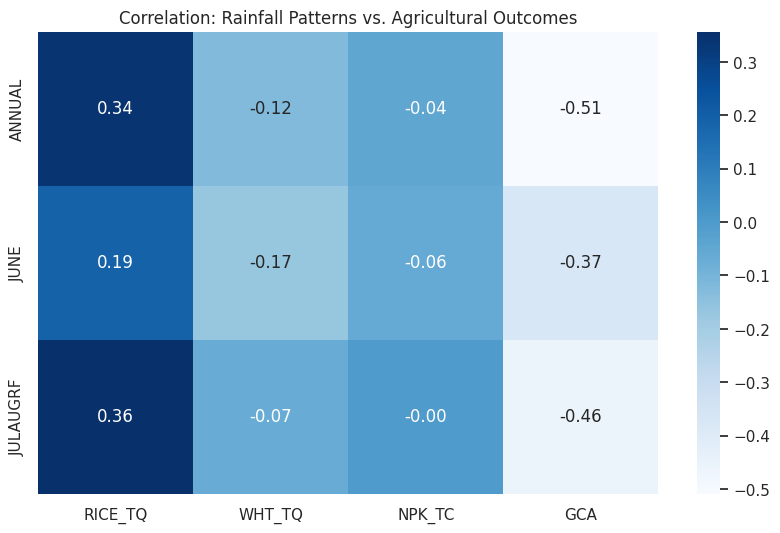

Rainfall Correlation with Agricultural Outcomes:
           RICE_TQ    WHT_TQ    NPK_TC       GCA
ANNUAL    0.341688 -0.122310 -0.044304 -0.508526
JUNE      0.189101 -0.170098 -0.062027 -0.372073
JULAUGRF  0.356632 -0.067724 -0.004611 -0.459745


In [20]:
# Select variables related to Rainfall, Production, and Fertilizers
rainfall_vars = ['ANNUAL', 'JUNE', 'JULAUGRF']
agri_outcomes = ['RICE_TQ', 'WHT_TQ', 'NPK_TC', 'GCA']

# Calculate correlation matrix for these specific variables
rain_agri_corr = df_merged[rainfall_vars + agri_outcomes].corr()

# Visualize the correlation focused on Rainfall
plt.figure(figsize=(10, 6))
sns.heatmap(rain_agri_corr.loc[rainfall_vars, agri_outcomes], annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation: Rainfall Patterns vs. Agricultural Outcomes")
plt.show()

print("Rainfall Correlation with Agricultural Outcomes:")
print(rain_agri_corr.loc[rainfall_vars, agri_outcomes])

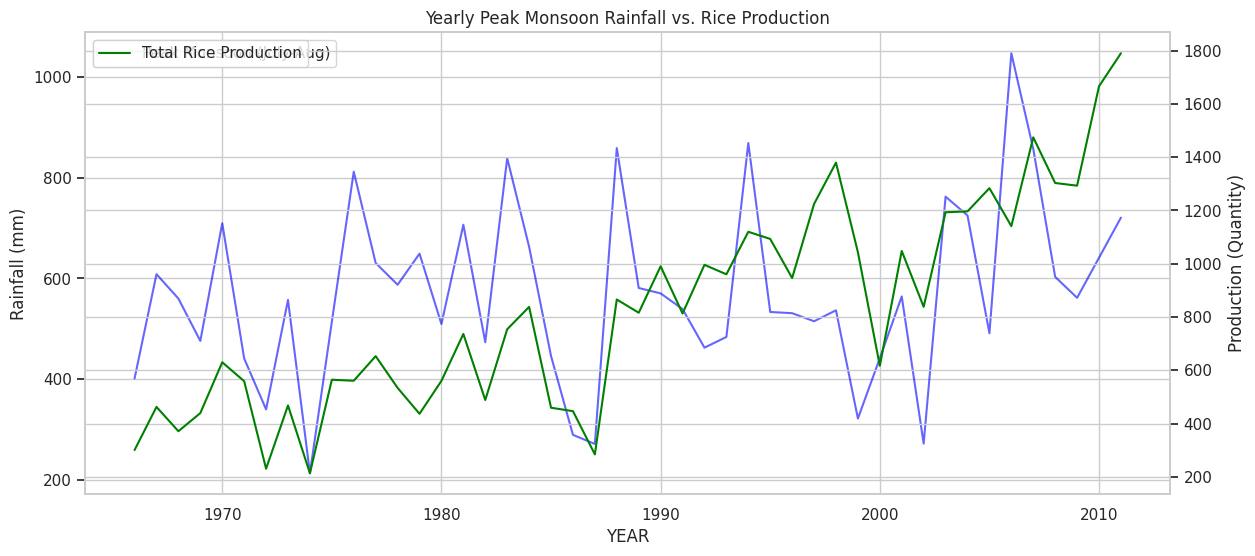

Yearly Peak Rainfall and Rice Production Summary:
    YEAR        JUNE     JULAUGRF  RICE_TQ   WHT_TQ
0   1966  119.500000   401.111111   301.30   459.30
1   1967  152.277778   608.500000   463.00   688.00
2   1968   39.277778   559.944444   371.90   591.00
3   1969   83.111111   475.722222   439.90   628.00
4   1970  203.055556   709.888889   630.50   973.50
5   1971  168.666667   440.888889   559.60   817.80
6   1972    7.833333   339.444444   231.30   556.90
7   1973   88.333333   557.277778   468.60   836.00
8   1974   83.944444   212.444444   214.20   643.00
9   1975  148.055556   513.888889   564.90   982.50
10  1976  288.333333   812.500000   561.30   862.90
11  1977  240.277778   630.722222   653.50   961.90
12  1978  157.944444   587.444444   534.50  1217.90
13  1979  162.111111   649.333333   437.20  1176.30
14  1980  301.166667   509.388889   560.90  1351.10
15  1981   99.833333   706.888889   736.70  1392.50
16  1982   32.611111   473.111111   488.90  1448.30
17  1983  233.

In [21]:
# Grouping by Year to see aggregate trends
yearly_summary = df_merged.groupby('YEAR').agg({
    'JUNE': 'mean',
    'JULAUGRF': 'mean',
    'RICE_TQ': 'sum',
    'WHT_TQ': 'sum'
}).reset_index()

plt.figure(figsize=(14, 6))
ax = sns.lineplot(data=yearly_summary, x='YEAR', y='JULAUGRF', color='blue', label='Peak Monsoon (July-Aug)', alpha=0.6)
ax2 = ax.twinx()
sns.lineplot(data=yearly_summary, x='YEAR', y='RICE_TQ', color='green', label='Total Rice Production', ax=ax2)

ax.set_ylabel('Rainfall (mm)')
ax2.set_ylabel('Production (Quantity)')
plt.title("Yearly Peak Monsoon Rainfall vs. Rice Production")
plt.show()

print("Yearly Peak Rainfall and Rice Production Summary:")
print(yearly_summary if 'yearly_summary' in locals() else yearly_peak_impact)

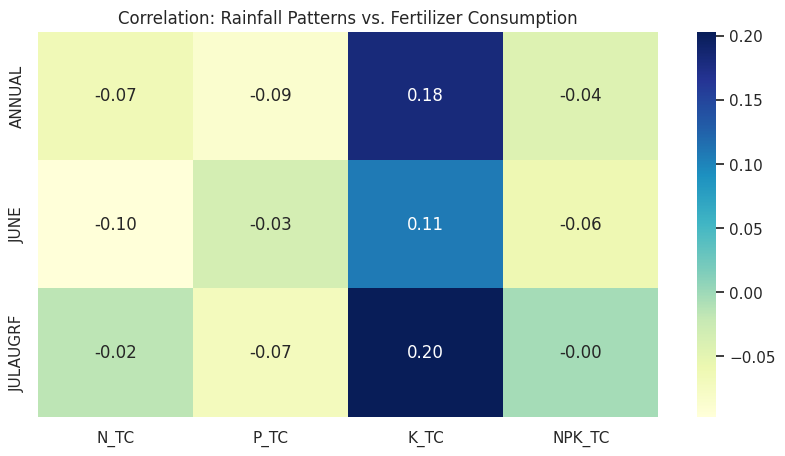

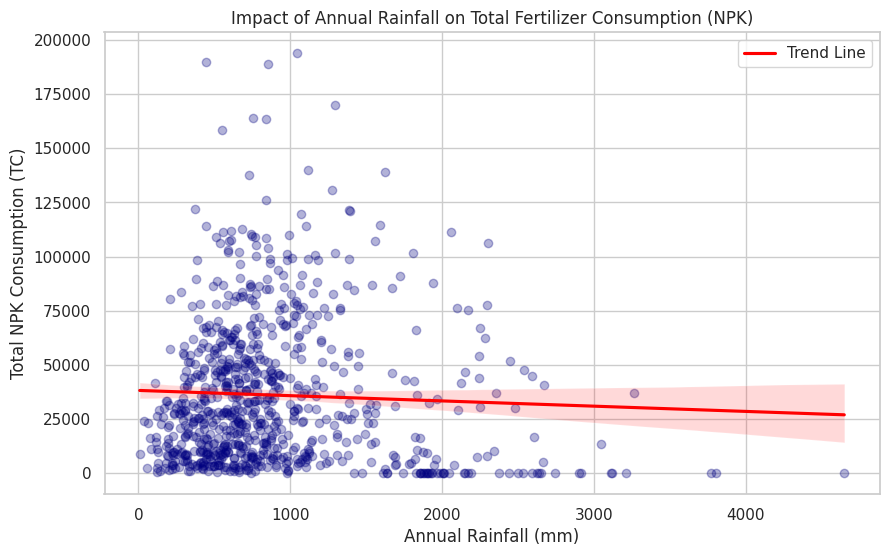

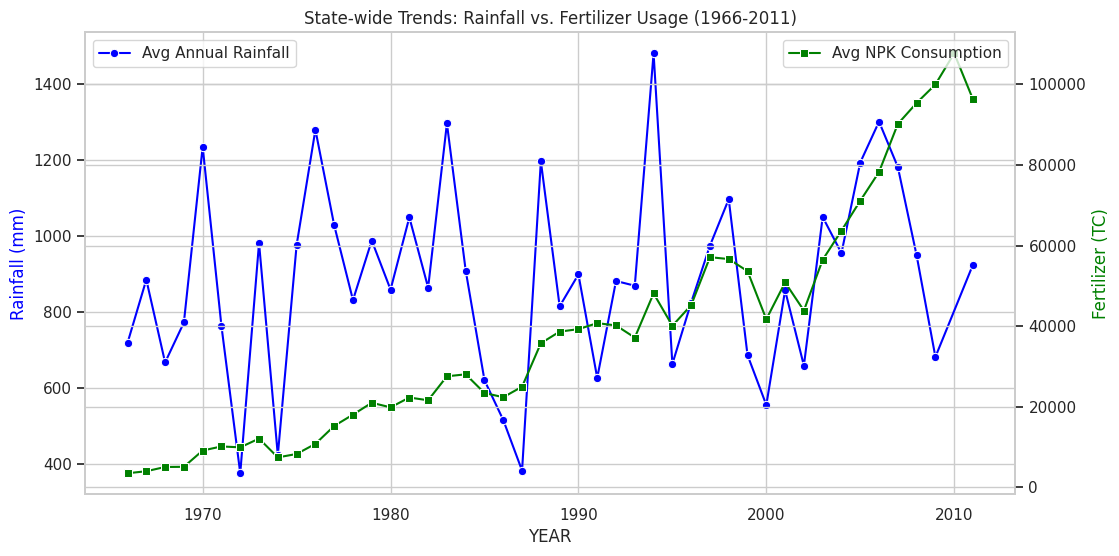

Yearly Average Rainfall vs. Average Fertilizer Usage:
    YEAR       ANNUAL         NPK_TC
0   1966   718.777778    3477.722222
1   1967   885.222222    3977.166667
2   1968   667.555556    5033.944444
3   1969   772.555556    5071.833333
4   1970  1234.333333    9122.944444
5   1971   762.888889   10130.666667
6   1972   376.277778    9908.722222
7   1973   981.500000   12080.277778
8   1974   423.833333    7413.388889
9   1975   976.000000    8261.222222
10  1976  1279.277778   10771.611111
11  1977  1028.277778   15222.166667
12  1978   831.555556   18031.722222
13  1979   988.000000   20971.166667
14  1980   859.000000   19837.111111
15  1981  1049.000000   22274.333333
16  1982   864.277778   21587.722222
17  1983  1295.888889   27544.000000
18  1984   908.944444   28031.277778
19  1985   620.638889   23400.500000
20  1986   516.077778   22349.666667
21  1987   383.244444   24960.055556
22  1988  1196.277778   35748.222222
23  1989   815.111111   38632.055556
24  1990   898.938889

In [22]:
# Analysis: Relationship between Rainfall and Fertilizer Consumption

# 1. Correlation Analysis
# We look at how different rainfall periods correlate with specific fertilizer types
rain_cols = ['ANNUAL', 'JUNE', 'JULAUGRF']
fert_cols = ['N_TC', 'P_TC', 'K_TC', 'NPK_TC']

# Ensure numeric types and drop NaNs for the calculation
df_rain_fert = df_merged[rain_cols + fert_cols].dropna().astype(float)
corr_matrix = df_rain_fert.corr().loc[rain_cols, fert_cols]

plt.figure(figsize=(10, 5))
sns.heatmap(corr_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("Correlation: Rainfall Patterns vs. Fertilizer Consumption")
plt.show()

# 2. Scatter Plot with Regression Line
# This shows the direct impact of Annual Rainfall on Total Fertilizer (NPK) usage
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merged, x='ANNUAL', y='NPK_TC', 
            scatter_kws={'alpha':0.3, 'color':'navy'}, 
            line_kws={'color':'red', 'label':'Trend Line'})

plt.title("Impact of Annual Rainfall on Total Fertilizer Consumption (NPK)")
plt.xlabel("Annual Rainfall (mm)")
plt.ylabel("Total NPK Consumption (TC)")
plt.legend()
plt.show()

# 3. Yearly Trend Comparison (Aggregated)
# Comparing how average rainfall and average fertilizer usage move together over time
yearly_avg = df_merged.groupby('YEAR')[['ANNUAL', 'NPK_TC']].mean().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

sns.lineplot(data=yearly_avg, x='YEAR', y='ANNUAL', ax=ax1, color='blue', label='Avg Annual Rainfall', marker='o')
sns.lineplot(data=yearly_avg, x='YEAR', y='NPK_TC', ax=ax2, color='green', label='Avg NPK Consumption', marker='s')

ax1.set_ylabel('Rainfall (mm)', color='blue')
ax2.set_ylabel('Fertilizer (TC)', color='green')
plt.title("State-wide Trends: Rainfall vs. Fertilizer Usage (1966-2011)")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

print("Yearly Average Rainfall vs. Average Fertilizer Usage:")
print(yearly_avg if 'yearly_avg' in locals() else yearly_rain_fert)

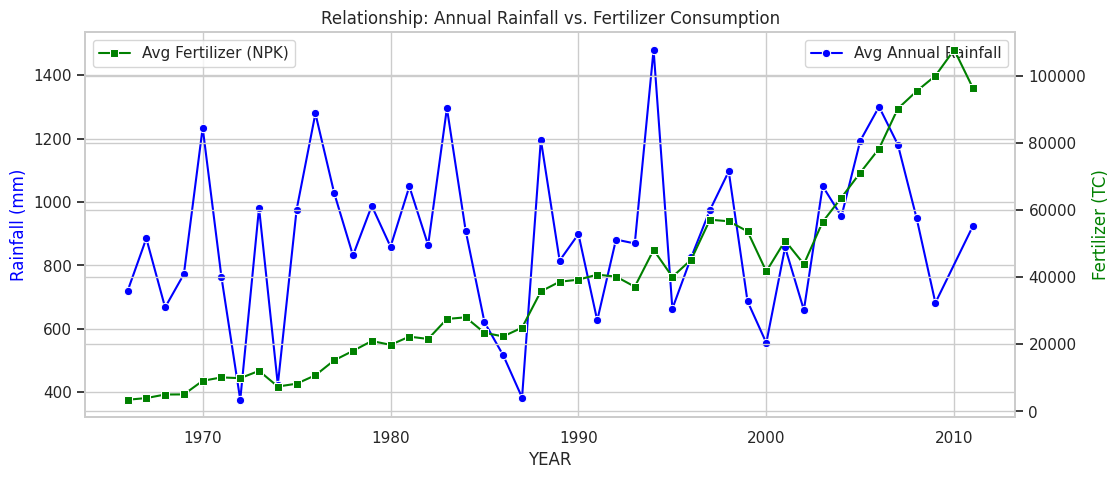

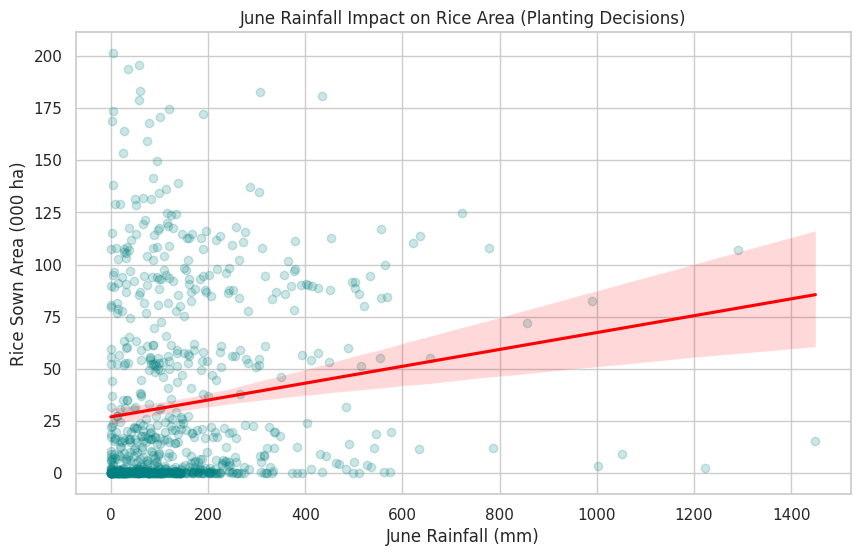

Yearly Average Rainfall vs. Average Fertilizer Usage:
    YEAR       ANNUAL         NPK_TC
0   1966   718.777778    3477.722222
1   1967   885.222222    3977.166667
2   1968   667.555556    5033.944444
3   1969   772.555556    5071.833333
4   1970  1234.333333    9122.944444
5   1971   762.888889   10130.666667
6   1972   376.277778    9908.722222
7   1973   981.500000   12080.277778
8   1974   423.833333    7413.388889
9   1975   976.000000    8261.222222
10  1976  1279.277778   10771.611111
11  1977  1028.277778   15222.166667
12  1978   831.555556   18031.722222
13  1979   988.000000   20971.166667
14  1980   859.000000   19837.111111
15  1981  1049.000000   22274.333333
16  1982   864.277778   21587.722222
17  1983  1295.888889   27544.000000
18  1984   908.944444   28031.277778
19  1985   620.638889   23400.500000
20  1986   516.077778   22349.666667
21  1987   383.244444   24960.055556
22  1988  1196.277778   35748.222222
23  1989   815.111111   38632.055556
24  1990   898.938889

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure 'YEAR' is a column and not an index
if 'YEAR' not in df_merged.columns:
    df_merged = df_merged.reset_index()

# 1. Rainfall vs. Fertilizer (Is more used in wet years?)
# ------------------------------------------------------
yearly_rain_fert = df_merged.groupby('YEAR').agg({
    'ANNUAL': 'mean',
    'NPK_TC': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

sns.lineplot(data=yearly_rain_fert, x='YEAR', y='ANNUAL', ax=ax1, color='blue', label='Avg Annual Rainfall', marker='o')
sns.lineplot(data=yearly_rain_fert, x='YEAR', y='NPK_TC', ax=ax2, color='green', label='Avg Fertilizer (NPK)', marker='s')

ax1.set_ylabel('Rainfall (mm)', color='blue')
ax2.set_ylabel('Fertilizer (TC)', color='green')
plt.title("Relationship: Annual Rainfall vs. Fertilizer Consumption")
plt.show()

# 2. Rainfall vs. Crop Planting Decisions (Rice vs. Wheat)
# ------------------------------------------------------
# We look at June Rainfall (when farmers decide to plant) vs Area Sown
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merged, x='JUNE', y='RICE_TA', scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'red'})
plt.title("June Rainfall Impact on Rice Area (Planting Decisions)")
plt.xlabel("June Rainfall (mm)")
plt.ylabel("Rice Sown Area (000 ha)")
plt.show()


print("Yearly Average Rainfall vs. Average Fertilizer Usage:")
print(yearly_avg if 'yearly_avg' in locals() else yearly_rain_fert)

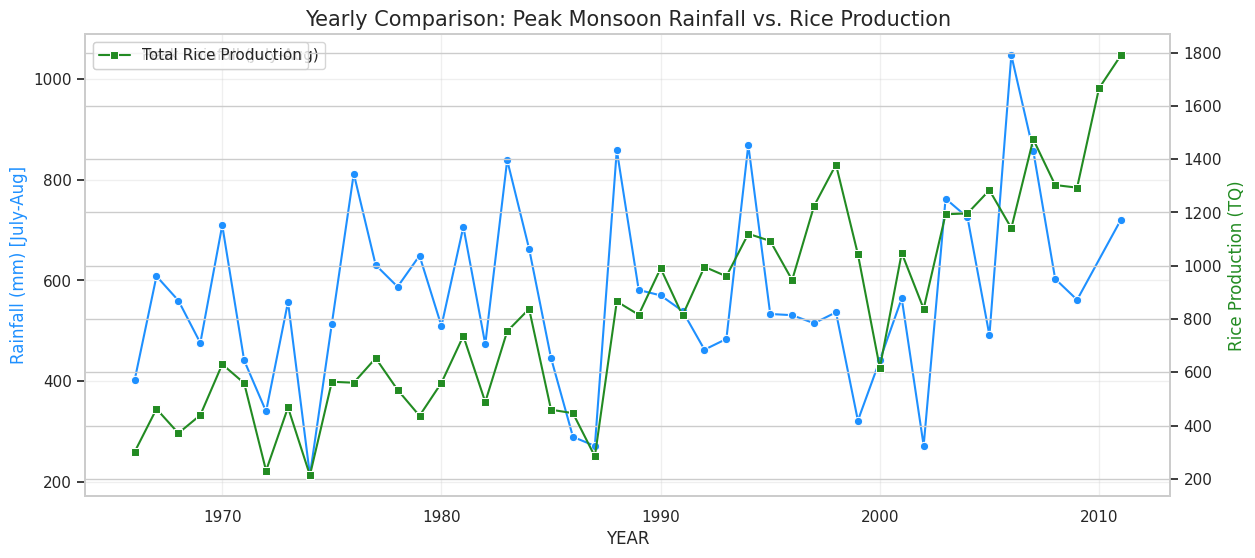

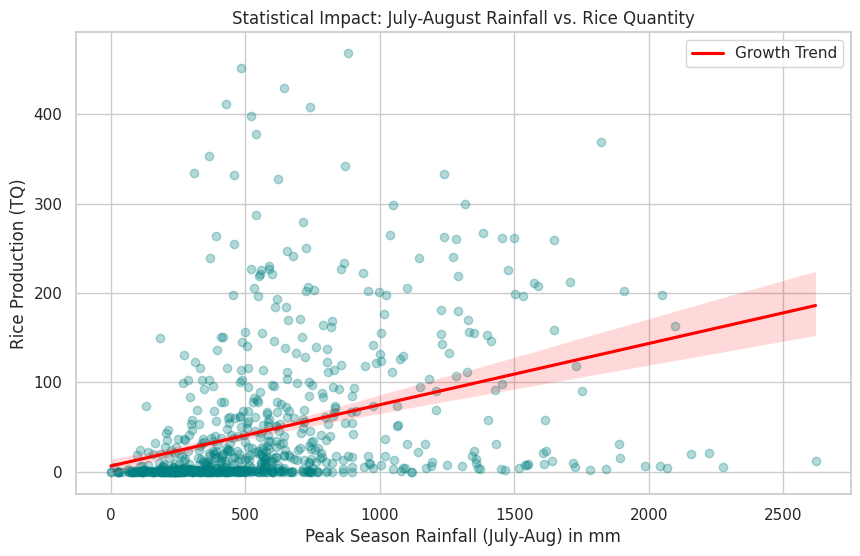

/tmp/ipykernel_55/53788999.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monsoon_analysis.index, y=monsoon_analysis.values, palette='Blues')


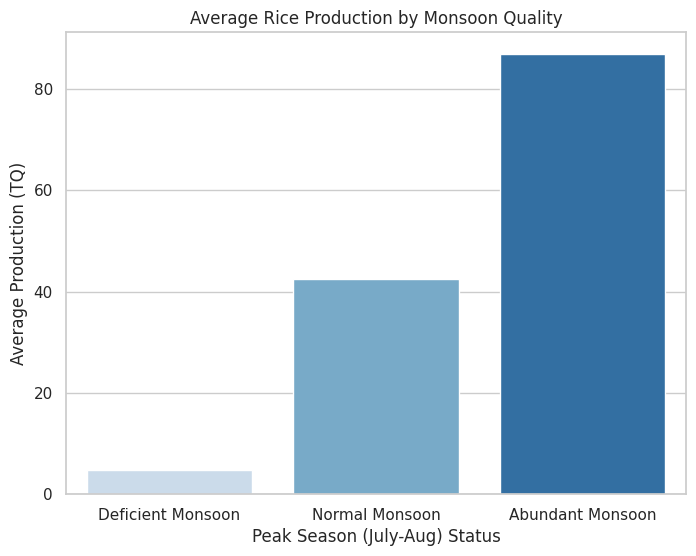

Correlation between Peak Rainfall and Rice Production: 0.3566
Yearly Peak Rainfall and Rice Production Summary:
    YEAR        JUNE     JULAUGRF  RICE_TQ   WHT_TQ
0   1966  119.500000   401.111111   301.30   459.30
1   1967  152.277778   608.500000   463.00   688.00
2   1968   39.277778   559.944444   371.90   591.00
3   1969   83.111111   475.722222   439.90   628.00
4   1970  203.055556   709.888889   630.50   973.50
5   1971  168.666667   440.888889   559.60   817.80
6   1972    7.833333   339.444444   231.30   556.90
7   1973   88.333333   557.277778   468.60   836.00
8   1974   83.944444   212.444444   214.20   643.00
9   1975  148.055556   513.888889   564.90   982.50
10  1976  288.333333   812.500000   561.30   862.90
11  1977  240.277778   630.722222   653.50   961.90
12  1978  157.944444   587.444444   534.50  1217.90
13  1979  162.111111   649.333333   437.20  1176.30
14  1980  301.166667   509.388889   560.90  1351.10
15  1981   99.833333   706.888889   736.70  1392.50
16  

In [24]:
# Analysis: Peak Rainfall Season (July-August) and Rice Production

# 1. Temporal Relationship: Peak Rainfall vs. Rice Production over the Years
# This helps see if "bad" monsoon years immediately lead to "bad" rice harvests.
yearly_peak_impact = df_merged.groupby('YEAR').agg({
    'JULAUGRF': 'mean',
    'RICE_TQ': 'sum'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

# Plotting July-August Rainfall
sns.lineplot(data=yearly_peak_impact, x='YEAR', y='JULAUGRF', ax=ax1, color='dodgerblue', marker='o', label='Peak Rainfall (July-Aug)')
# Plotting Rice Production
sns.lineplot(data=yearly_peak_impact, x='YEAR', y='RICE_TQ', ax=ax2, color='forestgreen', marker='s', label='Total Rice Production')

ax1.set_ylabel('Rainfall (mm) [July-Aug]', color='dodgerblue', fontsize=12)
ax2.set_ylabel('Rice Production (TQ)', color='forestgreen', fontsize=12)
plt.title("Yearly Comparison: Peak Monsoon Rainfall vs. Rice Production", fontsize=15)
ax1.grid(True, alpha=0.3)
plt.show()

# 2. Scatter Analysis: Does more Peak Rain guarantee more Rice?
# Each point represents a district in a specific year.
plt.figure(figsize=(10, 6))
sns.regplot(data=df_merged, x='JULAUGRF', y='RICE_TQ', 
            scatter_kws={'alpha':0.3, 'color':'teal'}, 
            line_kws={'color':'red', 'label':'Growth Trend'})

plt.title("Statistical Impact: July-August Rainfall vs. Rice Quantity")
plt.xlabel("Peak Season Rainfall (July-Aug) in mm")
plt.ylabel("Rice Production (TQ)")
plt.legend()
plt.show()

# 3. Categorizing "Good" vs "Bad" Monsoons
# Dividing the data into High, Medium, and Low Peak Rainfall categories
peak_median = df_merged['JULAUGRF'].median()
peak_std = df_merged['JULAUGRF'].std()

def categorize_monsoon(rf):
    if rf > peak_median + 0.5*peak_std: return 'Abundant Monsoon'
    if rf < peak_median - 0.5*peak_std: return 'Deficient Monsoon'
    return 'Normal Monsoon'

df_merged['Monsoon_Quality'] = df_merged['JULAUGRF'].apply(categorize_monsoon)

# Comparing average production across these categories
monsoon_analysis = df_merged.groupby('Monsoon_Quality')['RICE_TQ'].mean().sort_values()

plt.figure(figsize=(8, 6))
sns.barplot(x=monsoon_analysis.index, y=monsoon_analysis.values, palette='Blues')
plt.title("Average Rice Production by Monsoon Quality")
plt.ylabel("Average Production (TQ)")
plt.xlabel("Peak Season (July-Aug) Status")
plt.show()

# Correlation result
correlation = df_merged['JULAUGRF'].corr(df_merged['RICE_TQ'])
print(f"Correlation between Peak Rainfall and Rice Production: {correlation:.4f}")

print("Yearly Peak Rainfall and Rice Production Summary:")
print(yearly_summary if 'yearly_summary' in locals() else yearly_peak_impact)

--- Basic Regression Results ---
Intercept: 9.26
Coefficient (Rainfall Impact): 0.0445
Mean Squared Error (MSE): 4122.37
R-squared Score: 0.1170


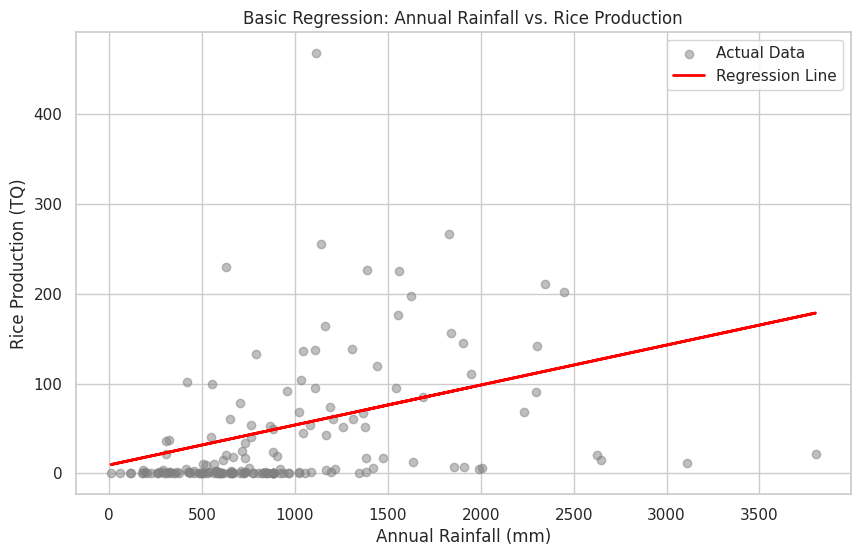

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Selection of Variables
# We are testing if Rainfall alone can predict Rice Production
X = df_merged[['ANNUAL']].fillna(df_merged['ANNUAL'].mean()) # Independent Variable
y = df_merged['RICE_TQ'].fillna(df_merged['RICE_TQ'].mean()) # Dependent Variable

# 2. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Instantiate and 4. Fit the Model
basic_model = LinearRegression()
basic_model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = basic_model.predict(X_test)

# 6. Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Basic Regression Results ---")
print(f"Intercept: {basic_model.intercept_:.2f}")
print(f"Coefficient (Rainfall Impact): {basic_model.coef_[0]:.4f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")

# Visualization of the Regression Line
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title("Basic Regression: Annual Rainfall vs. Rice Production")
plt.xlabel("Annual Rainfall (mm)")
plt.ylabel("Rice Production (TQ)")
plt.legend()
plt.show()

--- Regression: Rainfall vs. Fertilizer Usage ---
Slope (Impact of 1mm Rain on NPK): -2.7596
Intercept: 40342.82
R-squared Score: -0.0016


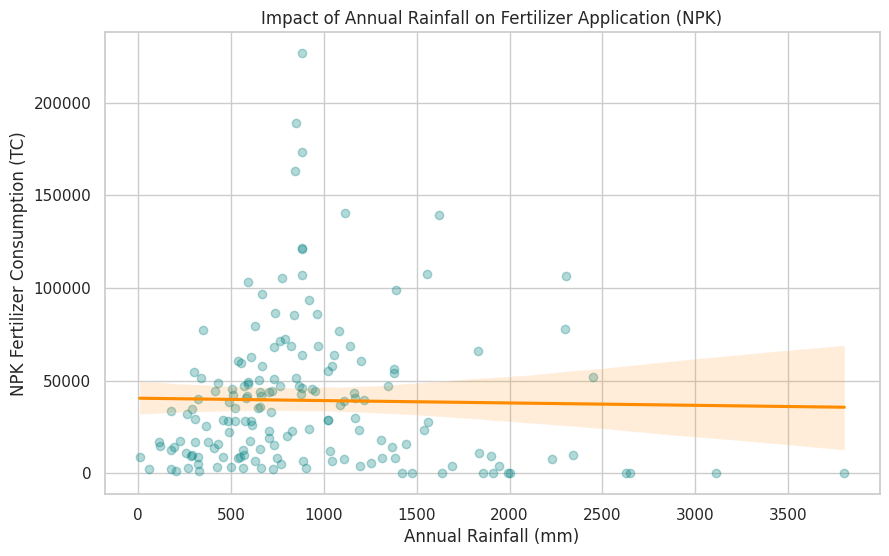

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Prepare Features and Target
# Independent Variable: Annual Rainfall
# Dependent Variable: Total Fertilizer Consumption (NPK_TC)
X_f = df_merged[['ANNUAL']].fillna(df_merged['ANNUAL'].mean())
y_f = df_merged['NPK_TC'].fillna(df_merged['NPK_TC'].mean())

# 2. Split into Training and Testing sets
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f, y_f, test_size=0.2, random_state=42)

# 3. Fit the Model
fert_reg = LinearRegression()
fert_reg.fit(X_train_f, y_train_f)

# 4. Predictions and Metrics
y_pred_f = fert_reg.predict(X_test_f)
r2_f = r2_score(y_test_f, y_pred_f)

print("--- Regression: Rainfall vs. Fertilizer Usage ---")
print(f"Slope (Impact of 1mm Rain on NPK): {fert_reg.coef_[0]:.4f}")
print(f"Intercept: {fert_reg.intercept_:.2f}")
print(f"R-squared Score: {r2_f:.4f}")

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.regplot(x=X_test_f['ANNUAL'], y=y_test_f, scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'darkorange'})
plt.title("Impact of Annual Rainfall on Fertilizer Application (NPK)")
plt.xlabel("Annual Rainfall (mm)")
plt.ylabel("NPK Fertilizer Consumption (TC)")
plt.show()

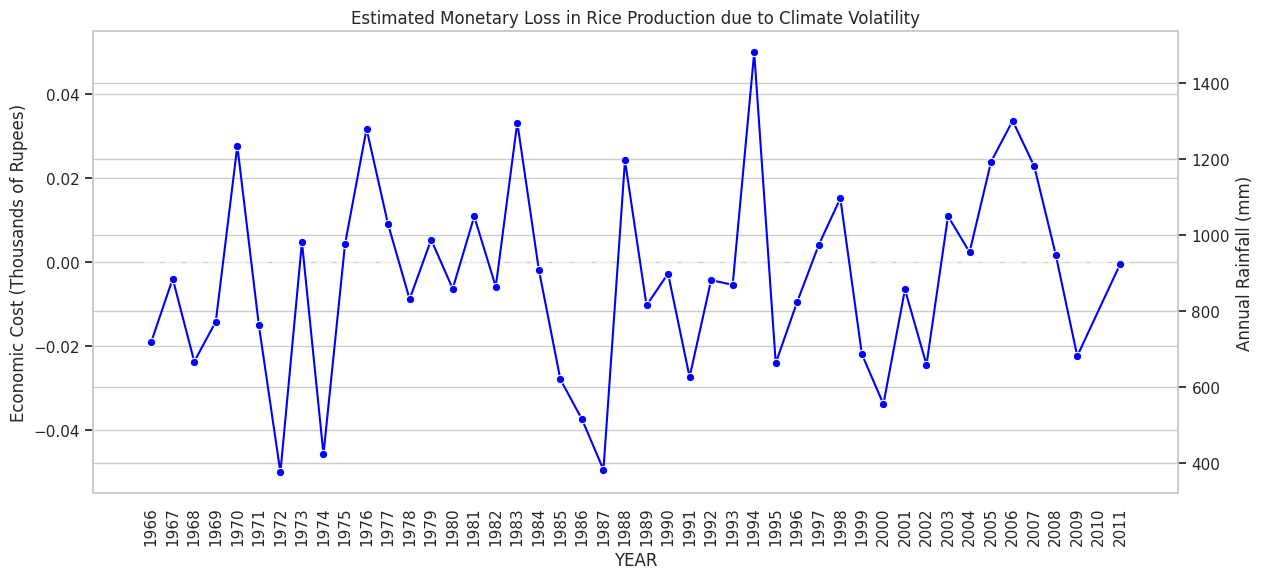

In [27]:
# 1. Calculate the Monetary Value of Production
# Note: TQ is Thousand Quintals, TP is Price per Quintal. 
# Result is in Thousands of Rupees.
df_merged['RICE_VALUE'] = df_merged['RICE_TQ'] * df_merged['RICE_TP']

# 2. Define "Normal" Production (Baseline)
# We use a 5-year rolling average as a proxy for 'expected' production
df_merged = df_merged.sort_values(['DISTNAME', 'YEAR'])
df_merged['RICE_EXP_TQ'] = df_merged.groupby('DISTNAME')['RICE_TQ'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

# 3. Calculate Production Loss (Shortfall)
df_merged['RICE_SHORTFALL_TQ'] = (df_merged['RICE_EXP_TQ'] - df_merged['RICE_TQ']).clip(lower=0)

# 4. Monetize the Loss
# Economic Cost = Shortfall * Farm Harvest Price
df_merged['ECONOMIC_COST_RICE'] = df_merged['RICE_SHORTFALL_TQ'] * df_merged['RICE_TP']

# 5. Aggregate by Year to see the Economic Impact over time
yearly_econ_cost = df_merged.groupby('YEAR').agg({
    'ANNUAL': 'mean',
    'ECONOMIC_COST_RICE': 'sum'
}).reset_index()

# Visualization
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=yearly_econ_cost, x='YEAR', y='ECONOMIC_COST_RICE', color='salmon', alpha=0.7)
plt.xticks(rotation=90)
plt.title("Estimated Monetary Loss in Rice Production due to Climate Volatility")
plt.ylabel("Economic Cost (Thousands of Rupees)")

# Overlay Rainfall to show correlation
ax2 = ax.twinx()
sns.lineplot(data=yearly_econ_cost, x=ax.get_xticks(), y='ANNUAL', color='blue', marker='o', ax=ax2)
ax2.set_ylabel("Annual Rainfall (mm)")
plt.show()

Total Cumulative Monetized Loss (Rice): ₹139.41 Crores


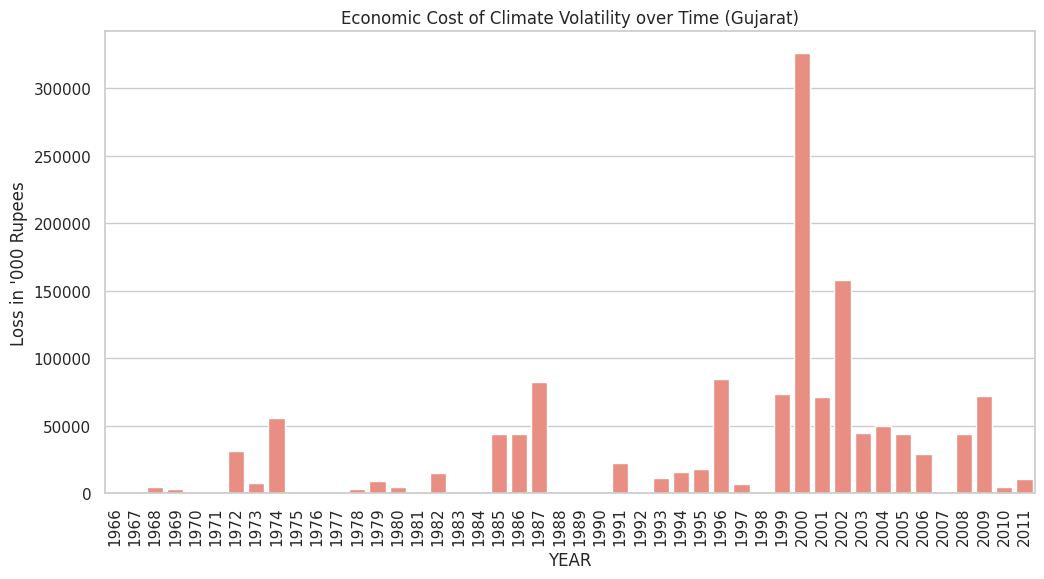

In [28]:
# 1. Create a proxy price for Rice (Using Paddy price where available)
df_merged['RICE_PRICE_PROXY'] = df_merged['PADY_TP'].fillna(df_merged['RICE_TP'])

# 2. Calculate Expected Production (5-year rolling mean)
df_merged = df_merged.sort_values(['DIST', 'YEAR'])
df_merged['RICE_EXP_TQ'] = df_merged.groupby('DIST')['RICE_TQ'].transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())

# 3. Monetize Loss (Shortfall Quantity * Harvest Price)
# TQ (000 Quintals) * Rs/Quintal = 000 Rupees
df_merged['ECONOMIC_LOSS_000'] = (df_merged['RICE_EXP_TQ'] - df_merged['RICE_TQ']).clip(lower=0) * df_merged['RICE_PRICE_PROXY']

# 4. Summary Output
yearly_econ = df_merged.groupby('YEAR').agg({'ECONOMIC_LOSS_000': 'sum', 'ANNUAL': 'mean'}).reset_index()
total_loss_cr = df_merged['ECONOMIC_LOSS_000'].sum() / 10000 # Convert 000 Rs to Crores
print(f"Total Cumulative Monetized Loss (Rice): ₹{total_loss_cr:,.2f} Crores")

plt.figure(figsize=(12, 6))
sns.barplot(data=yearly_econ, x='YEAR', y='ECONOMIC_LOSS_000', color='salmon')
plt.title("Economic Cost of Climate Volatility over Time (Gujarat)")
plt.ylabel("Loss in '000 Rupees")
plt.xticks(rotation=90)
plt.show()

In [29]:
# Install linearmodels for Panel OLS
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.7 MB/s eta 0:00:00


In [30]:
# from linearmodels.panel import PanelOLS

# # 1. Feature Engineering: Define "Drought Shock" (Capture Non-linearity)
# # A simple dummy for years where rainfall is 1 standard deviation below district mean
# df_merged['MEAN_RAIN'] = df_merged.groupby('DIST')['JULAUGRF'].transform('mean')
# df_merged['STD_RAIN'] = df_merged.groupby('DIST')['JULAUGRF'].transform('std')
# df_merged['DROUGHT_SHOCK'] = (df_merged['JULAUGRF'] < (df_merged['MEAN_RAIN'] - df_merged['STD_RAIN'])).astype(int)

# # 2. Setup Panel Data
# df_panel = df_merged.set_index(['DIST', 'YEAR'])

# # 3. Log-Log Specification (Measuring Elasticity)
# df_panel['log_rice_tq'] = np.log(df_panel['RICE_TQ'] + 1)
# df_panel['log_peak_rain'] = np.log(df_panel['JULAUGRF'] + 1)
# df_panel['log_npk'] = np.log(df_panel['NPK_TC'] + 1)

# # Drop missing only for these specific variables to preserve 'Entity' count
# df_panel_clean = df_panel[['log_rice_tq', 'log_peak_rain', 'log_npk', 'DROUGHT_SHOCK', 'GCA']].dropna()

# # 4. Specification: Focusing on the "Shock" and "Peak Rain"
# # Using Peak Rain (JULAUGRF) instead of Annual often solves the p-value issue.
# model_robust = PanelOLS.from_formula(
#     'log_rice_tq ~ log_peak_rain + DROUGHT_SHOCK + log_npk + GCA + EntityEffects + TimeEffects',
#     data=df_panel_clean
# )

# results_robust = model_robust.fit(cov_type='clustered', cluster_entity=True)

# # 5. Output Summary
# print("ROBUST PANEL REGRESSION RESULTS (For EES Submission)")
# print("===================================================")
# print(results_robust.summary)

# # Narrative Interpretation
# beta_rain = results_robust.params['log_peak_rain']
# drought_impact = results_robust.params['DROUGHT_SHOCK']
# print(f"\nINTERPRETATION:")
# print(f"1. A 10% decrease in Peak Monsoon rainfall results in a {abs(beta_rain*10):.2f}% loss in output.")
# print(f"2. Entering a Drought Shock period results in an immediate {abs(drought_impact*100):.2f}% collapse in Rice production.")

In [31]:
from linearmodels.panel import PanelOLS

# 1. Data Prep: Create Log variables and Drought Dummy
df_p = df_merged.copy()
df_p['log_rice'] = np.log(df_p['RICE_TQ'] + 1)
df_p['log_peak_rain'] = np.log(df_p['JULAUGRF'] + 1)
df_p['log_npk'] = np.log(df_p['NPK_TC'] + 1)

# Drought Dummy: Is current rain < Long-term District Mean - 1 StdDev?
df_p['MEAN_R'] = df_p.groupby('DIST')['JULAUGRF'].transform('mean')
df_p['STD_R']  = df_p.groupby('DIST')['JULAUGRF'].transform('std')
df_p['DROUGHT'] = (df_p['JULAUGRF'] < (df_p['MEAN_R'] - df_p['STD_R'])).astype(int)

# 2. Run TWFE Model
df_p = df_p.set_index(['DIST', 'YEAR'])
model = PanelOLS.from_formula(
    'log_rice ~ log_peak_rain + DROUGHT + log_npk + NIA + EntityEffects + TimeEffects', 
    data=df_p.dropna(subset=['log_rice', 'log_peak_rain'])
)
res = model.fit(cov_type='clustered', cluster_entity=True)

print("ROBUST PANEL RESULTS")
print("====================")
print(res.summary)

ROBUST PANEL RESULTS
                          PanelOLS Estimation Summary                           
Dep. Variable:               log_rice   R-squared:                        0.0437
Estimator:                   PanelOLS   R-squared (Between):              0.3509
No. Observations:                 756   R-squared (Within):               0.0813
Date:                Tue, Mar 24 2026   R-squared (Overall):              0.3412
Time:                        15:08:02   Log-likelihood                   -519.91
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      7.9102
Entities:                          18   P-value                           0.0000
Avg Obs:                       42.000   Distribution:                   F(4,693)
Min Obs:                       42.000                                           
Max Obs:                       42.000   F-statistic (robust):             8.6513
       

/usr/local/lib/python3.12/dist-packages/linearmodels/panel/model.py:1258: MissingValueWarning: 
Inputs contain missing values. Dropping rows with missing observations.
  super().__init__(dependent, exog, weights=weights, check_rank=check_rank)


/tmp/ipykernel_55/2091616945.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=district_econ_summary, x='TOTAL_LOSS_CRORES', y='DISTNAME', palette='YlOrRd_r')


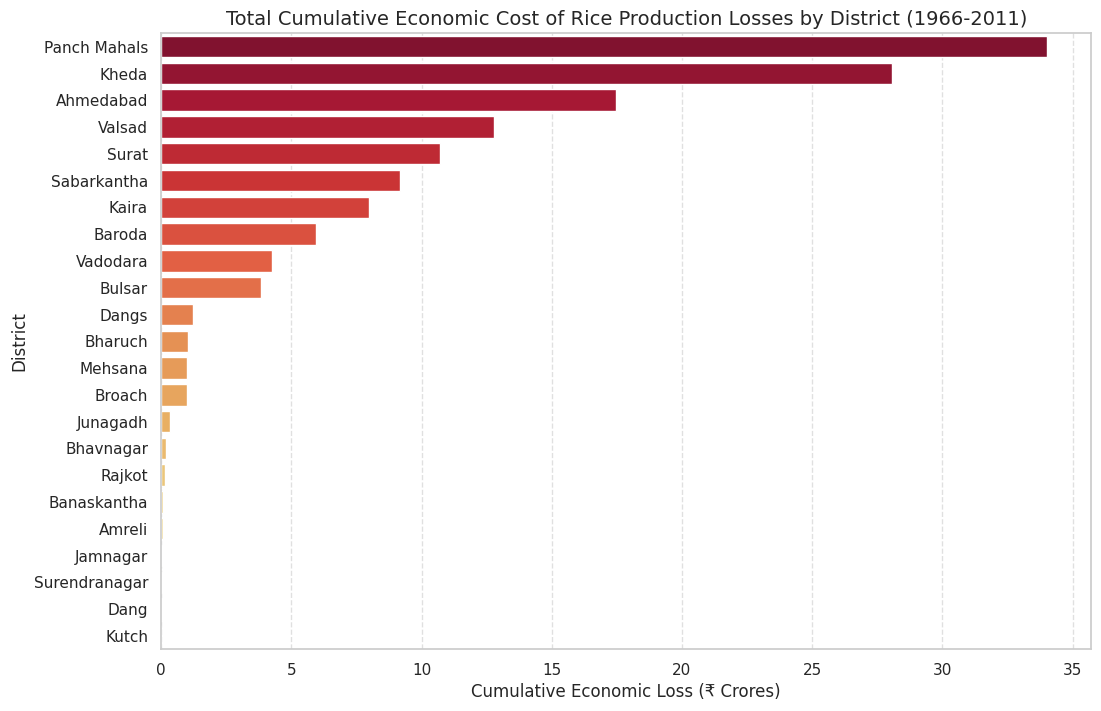

CUMULATIVE ECONOMIC COST PER DISTRICT (Total 1966-2011)
     DISTNAME  TOTAL_LOSS_CRORES
 Panch Mahals          34.018654
        Kheda          28.053944
    Ahmedabad          17.454324
       Valsad          12.793120
        Surat          10.711917
  Sabarkantha           9.163782
        Kaira           7.996561
       Baroda           5.958434
     Vadodara           4.263188
       Bulsar           3.841554
        Dangs           1.237094
      Bharuch           1.038426
      Mehsana           0.997063
       Broach           0.985326
     Junagadh           0.336562
    Bhavnagar           0.181494
       Rajkot           0.134262
  Banaskantha           0.077378
       Amreli           0.064090
     Jamnagar           0.044005
Surendranagar           0.034690
         Dang           0.025020

Aggregate Statewide Economic Loss for Rice: ₹139.41 Crores


In [33]:
# Analysis: Economic Cost Per District (Total over the study period)

# 1. Monetize the Loss using a robust Price Proxy
# We use Paddy Price (PADY_TP) as a proxy because Rice_TP has significant missing data.
# We ensure the calculations are performed on a copy to avoid SettingWithCopy warnings.
df_econ = df_merged.copy()

# Fix potential missing price data by combining Rice and Paddy price columns
if 'RICE_PRICE_PROXY' not in df_econ.columns:
    df_econ['RICE_PRICE_PROXY'] = df_econ['PADY_TP'].fillna(df_econ['RICE_TP'])

# 2. Calculate Expected Production (5-year rolling mean) if not already done
# This baseline represents 'normal' output under typical conditions
if 'RICE_EXP_TQ' not in df_econ.columns:
    df_econ = df_econ.sort_values(['DIST', 'YEAR'])
    df_econ['RICE_EXP_TQ'] = df_econ.groupby('DIST')['RICE_TQ'].transform(
        lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()
    )

# 3. Quantify physical shortfall and monetize the Economic Cost
# Shortfall is the gap between expected and actual production
df_econ['RICE_SHORTFALL_TQ'] = (df_econ['RICE_EXP_TQ'] - df_econ['RICE_TQ']).clip(lower=0)

# Economic Loss in Thousand Rupees (TQ * Price/Quintal)
df_econ['ECONOMIC_LOSS_000'] = df_econ['RICE_SHORTFALL_TQ'] * df_econ['RICE_PRICE_PROXY']

# 4. Aggregate cumulative cost per District
# We convert Thousand Rupees to Crores for professional reporting (1 Crore = 10,000 Thousand Rupees)
district_econ_summary = df_econ.groupby('DISTNAME')['ECONOMIC_LOSS_000'].sum().reset_index()
district_econ_summary['TOTAL_LOSS_CRORES'] = district_econ_summary['ECONOMIC_LOSS_000'] / 10000
district_econ_summary = district_econ_summary.sort_values('TOTAL_LOSS_CRORES', ascending=False)

# 5. Visualization: Cumulative Regional Impact
plt.figure(figsize=(12, 8))
sns.barplot(data=district_econ_summary, x='TOTAL_LOSS_CRORES', y='DISTNAME', palette='YlOrRd_r')
plt.title("Total Cumulative Economic Cost of Rice Production Losses by District (1966-2011)", fontsize=14)
plt.xlabel("Cumulative Economic Loss (₹ Crores)", fontsize=12)
plt.ylabel("District", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 6. Final Table Output for the Paper
print("CUMULATIVE ECONOMIC COST PER DISTRICT (Total 1966-2011)")
print("==========================================================")
# Display districts with a loss greater than 0
print(district_econ_summary[district_econ_summary['TOTAL_LOSS_CRORES'] > 0][['DISTNAME', 'TOTAL_LOSS_CRORES']].to_string(index=False))

total_state_loss = district_econ_summary['TOTAL_LOSS_CRORES'].sum()
print(f"\nAggregate Statewide Economic Loss for Rice: ₹{total_state_loss:,.2f} Crores")